Image shape: (300, 300, 3)
Image filename: cast_def_0_0.jpeg


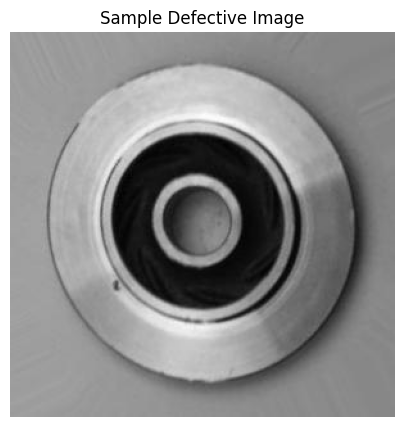

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to a defective image
base = r"C:\Users\ragha\Desktop\manufacturing-defect-detection\data\raw\archive\casting_data\casting_data"
def_path = os.path.join(base, "train", "def_front")

# Grab the first defective image
img_name = os.listdir(def_path)[0]
img_path = os.path.join(def_path, img_name)

# Load with OpenCV (note: OpenCV loads as BGR, not RGB)
img = cv2.imread(img_path)
print(f"Image shape: {img.shape}")
print(f"Image filename: {img_name}")

# Display it
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title("Sample Defective Image")
plt.axis("off")
plt.show()

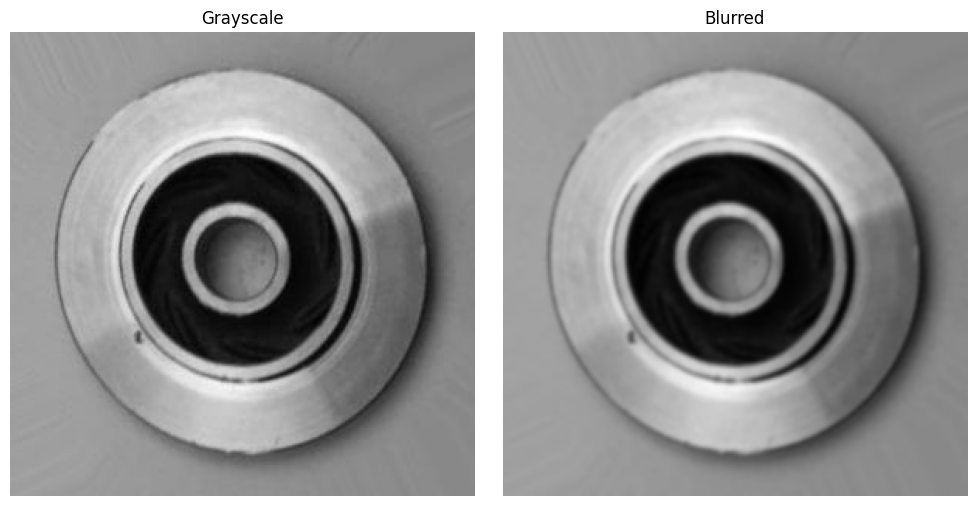

In [2]:
# Step 1: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Display both steps
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")

axes[1].imshow(blurred, cmap="gray")
axes[1].set_title("Blurred")
axes[1].axis("off")

plt.tight_layout()
plt.show()

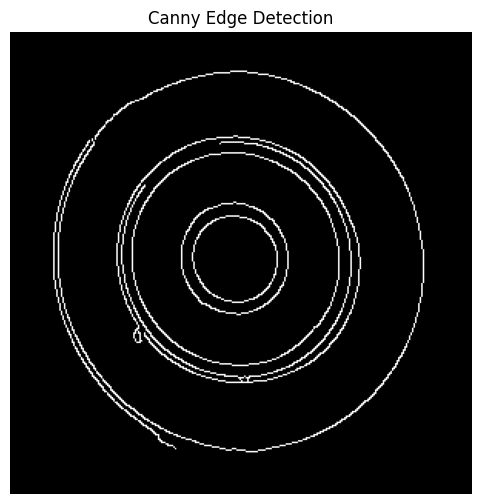

In [3]:
# Step 3: Edge detection using Canny
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

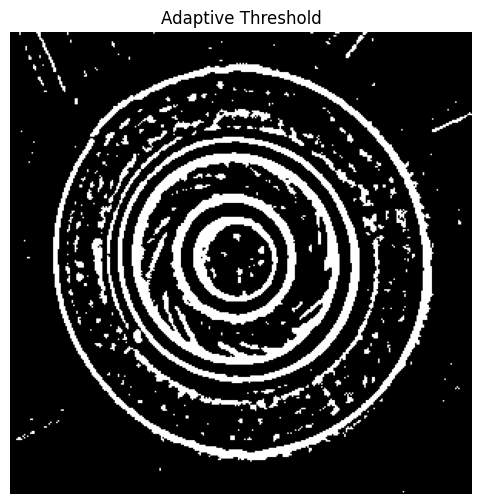

In [4]:
# Try adaptive thresholding to find irregular regions
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, blockSize=11, C=2
)

plt.figure(figsize=(6, 6))
plt.imshow(thresh, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

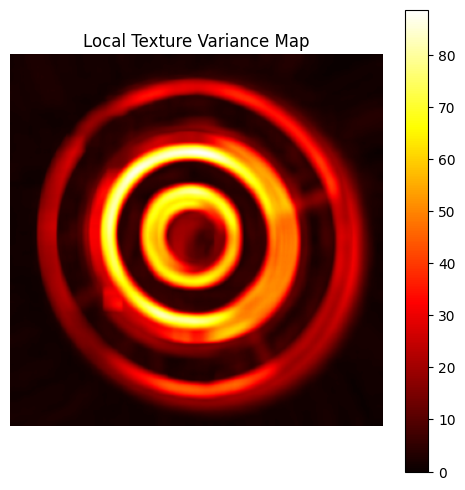

In [5]:
# Calculate local standard deviation - high std = irregular texture (likely defect)
def local_std(image, kernel_size=15):
    mean = cv2.blur(image.astype(float), (kernel_size, kernel_size))
    mean_sq = cv2.blur((image.astype(float))**2, (kernel_size, kernel_size))
    variance = mean_sq - mean**2
    std = np.sqrt(np.clip(variance, 0, None))
    return std

std_map = local_std(gray, kernel_size=15)

plt.figure(figsize=(6, 6))
plt.imshow(std_map, cmap="hot")
plt.title("Local Texture Variance Map")
plt.colorbar()
plt.axis("off")
plt.show()

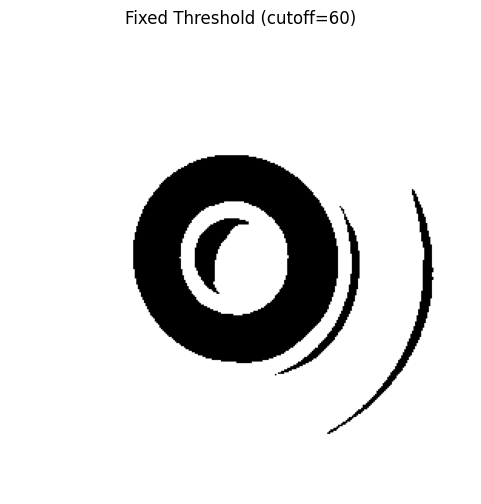

White pixels (above threshold): 77869
Total pixels: 90000


In [6]:
# Simple fixed thresholding approach
ret, simple_thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 6))
plt.imshow(simple_thresh, cmap="gray")
plt.title(f"Fixed Threshold (cutoff=60)")
plt.axis("off")
plt.show()

print(f"White pixels (above threshold): {np.sum(simple_thresh == 255)}")
print(f"Total pixels: {simple_thresh.size}")

Number of contours found: 4
Largest contour area: 13993.0 pixels
Percentage of total image: 15.55%


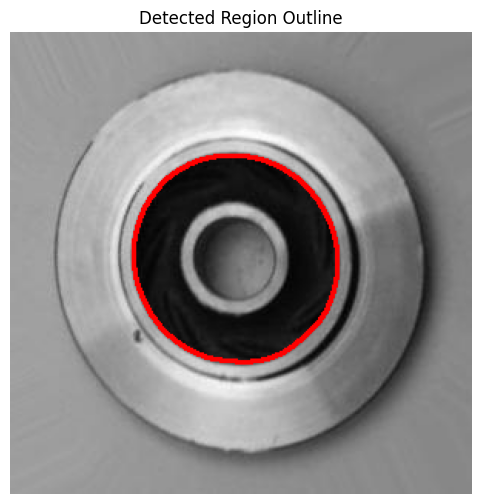

In [7]:
# Invert so the dark region becomes white (easier to find contours)
inverted = cv2.bitwise_not(simple_thresh)

# Find contours - boundaries of connected regions
contours, _ = cv2.findContours(inverted, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find the largest contour - this should be the dark inner compound region
largest_contour = max(contours, key=cv2.contourArea)
area = cv2.contourArea(largest_contour)

print(f"Number of contours found: {len(contours)}")
print(f"Largest contour area: {area} pixels")
print(f"Percentage of total image: {(area / simple_thresh.size) * 100:.2f}%")

# Draw the contour on the original image to visualize
img_with_contour = img_rgb.copy()
cv2.drawContours(img_with_contour, [largest_contour], -1, (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_with_contour)
plt.title("Detected Region Outline")
plt.axis("off")
plt.show()

Mean brightness inside region: 45.07
Std deviation inside region: 48.73


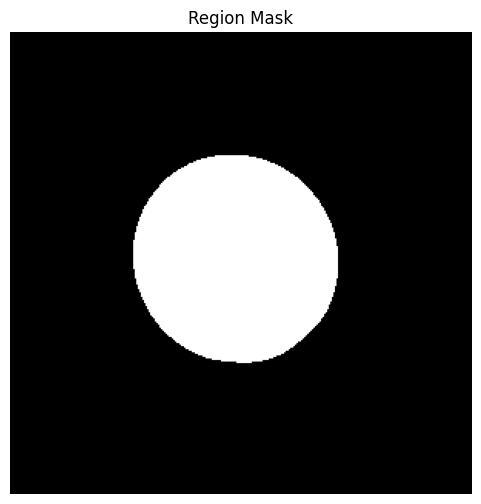

In [8]:
# Create a mask of just the dark inner region
mask = np.zeros_like(gray)
cv2.drawContours(mask, [largest_contour], -1, 255, -1)  # filled mask

# Extract pixel values only inside that region
masked_pixels = gray[mask == 255]

print(f"Mean brightness inside region: {masked_pixels.mean():.2f}")
print(f"Std deviation inside region: {masked_pixels.std():.2f}")

# Show the mask
plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Region Mask")
plt.axis("off")
plt.show()

In [9]:
def get_region_stats(image_path):
    """Process one image and return mean/std of the dark inner region"""
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    ret, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)
    inverted = cv2.bitwise_not(thresh)
    contours, _ = cv2.findContours(inverted, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return None, None
    
    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)
    
    masked_pixels = gray[mask == 255]
    if len(masked_pixels) == 0:
        return None, None
    
    return masked_pixels.mean(), masked_pixels.std()

# Test on 10 OK images and 10 defective images
ok_path = os.path.join(base, "train", "ok_front")
def_files = os.listdir(def_path)[:10]
ok_files = os.listdir(ok_path)[:10]

print("DEFECTIVE images:")
for f in def_files:
    mean, std = get_region_stats(os.path.join(def_path, f))
    print(f"  {f}: mean={mean:.2f}, std={std:.2f}")

print("\nOK images:")
for f in ok_files:
    mean, std = get_region_stats(os.path.join(ok_path, f))
    print(f"  {f}: mean={mean:.2f}, std={std:.2f}")

DEFECTIVE images:
  cast_def_0_0.jpeg: mean=45.07, std=48.73
  cast_def_0_1000.jpeg: mean=46.28, std=55.44
  cast_def_0_1001.jpeg: mean=51.85, std=48.59
  cast_def_0_1004.jpeg: mean=45.09, std=56.69
  cast_def_0_1007.jpeg: mean=48.16, std=56.52
  cast_def_0_1008.jpeg: mean=47.40, std=59.71
  cast_def_0_1014.jpeg: mean=43.62, std=49.42
  cast_def_0_1016.jpeg: mean=53.58, std=55.13
  cast_def_0_1019.jpeg: mean=44.64, std=54.94
  cast_def_0_1020.jpeg: mean=49.05, std=56.93

OK images:
  cast_ok_0_1.jpeg: mean=54.34, std=62.33
  cast_ok_0_1001.jpeg: mean=52.71, std=54.79
  cast_ok_0_1002.jpeg: mean=46.70, std=53.09
  cast_ok_0_1003.jpeg: mean=54.27, std=62.29
  cast_ok_0_1005.jpeg: mean=58.24, std=57.01
  cast_ok_0_1009.jpeg: mean=54.49, std=55.17
  cast_ok_0_101.jpeg: mean=54.79, std=61.82
  cast_ok_0_1013.jpeg: mean=54.62, std=57.09
  cast_ok_0_1016.jpeg: mean=58.87, std=57.17
  cast_ok_0_1019.jpeg: mean=54.68, std=56.69


In [10]:
def analyze_severity(image_path):
    """
    Estimate a severity proxy based on the irregular inner region area.
    NOTE: This is a simplified heuristic, not pixel-precise defect localization.
    It measures deviation in the inspected region's area as a proxy signal.
    """
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    ret, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY)
    inverted = cv2.bitwise_not(thresh)
    contours, _ = cv2.findContours(inverted, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return 0, "Unknown"
    
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    area_pct = (area / (gray.shape[0] * gray.shape[1])) * 100
    
    return area_pct, largest_contour

# Calculate area percentage for our sample sets
print("DEFECTIVE images - area %:")
def_areas = []
for f in def_files:
    area_pct, _ = analyze_severity(os.path.join(def_path, f))
    def_areas.append(area_pct)
    print(f"  {f}: {area_pct:.2f}%")

print("\nOK images - area %:")
ok_areas = []
for f in ok_files:
    area_pct, _ = analyze_severity(os.path.join(ok_path, f))
    ok_areas.append(area_pct)
    print(f"  {f}: {area_pct:.2f}%")

print(f"\nDefective avg: {np.mean(def_areas):.2f}%")
print(f"OK avg: {np.mean(ok_areas):.2f}%")

DEFECTIVE images - area %:
  cast_def_0_0.jpeg: 15.55%
  cast_def_0_1000.jpeg: 18.25%
  cast_def_0_1001.jpeg: 16.47%
  cast_def_0_1004.jpeg: 14.41%
  cast_def_0_1007.jpeg: 14.32%
  cast_def_0_1008.jpeg: 13.56%
  cast_def_0_1014.jpeg: 13.93%
  cast_def_0_1016.jpeg: 15.56%
  cast_def_0_1019.jpeg: 14.96%
  cast_def_0_1020.jpeg: 14.82%

OK images - area %:
  cast_ok_0_1.jpeg: 16.65%
  cast_ok_0_1001.jpeg: 15.05%
  cast_ok_0_1002.jpeg: 15.71%
  cast_ok_0_1003.jpeg: 16.66%
  cast_ok_0_1005.jpeg: 15.09%
  cast_ok_0_1009.jpeg: 15.56%
  cast_ok_0_101.jpeg: 16.66%
  cast_ok_0_1013.jpeg: 12.96%
  cast_ok_0_1016.jpeg: 15.05%
  cast_ok_0_1019.jpeg: 12.96%

Defective avg: 15.18%
OK avg: 15.23%


In [11]:
# Step 1: Build a baseline profile from OK images
ok_files_all = os.listdir(ok_path)[:50]  # use 50 OK images to build a stable baseline

baseline_means, baseline_stds, baseline_areas = [], [], []

for f in ok_files_all:
    full_path = os.path.join(ok_path, f)
    mean, std = get_region_stats(full_path)
    area_pct, _ = analyze_severity(full_path)
    if mean is not None:
        baseline_means.append(mean)
        baseline_stds.append(std)
        baseline_areas.append(area_pct)

baseline_mean_avg = np.mean(baseline_means)
baseline_std_avg = np.mean(baseline_stds)
baseline_area_avg = np.mean(baseline_areas)

baseline_mean_std = np.std(baseline_means)
baseline_std_std = np.std(baseline_stds)
baseline_area_std = np.std(baseline_areas)

print("Baseline profile from 50 OK images:")
print(f"  Mean brightness: {baseline_mean_avg:.2f} (variation: {baseline_mean_std:.2f})")
print(f"  Std deviation: {baseline_std_avg:.2f} (variation: {baseline_std_std:.2f})")
print(f"  Region area %: {baseline_area_avg:.2f} (variation: {baseline_area_std:.2f})")

Baseline profile from 50 OK images:
  Mean brightness: 51.57 (variation: 4.12)
  Std deviation: 56.51 (variation: 4.08)
  Region area %: 16.18 (variation: 1.69)


In [12]:
def calculate_severity(image_path, baseline_mean_avg, baseline_mean_std, 
                        baseline_std_avg, baseline_std_std,
                        baseline_area_avg, baseline_area_std):
    """
    Calculate a severity score based on deviation from the OK baseline.
    This is a relative anomaly score, not a precise defect measurement.
    """
    mean, std = get_region_stats(image_path)
    area_pct, _ = analyze_severity(image_path)
    
    if mean is None:
        return None, "Unknown"
    
    # Z-score: how many standard deviations away from baseline is this image?
    z_mean = abs(mean - baseline_mean_avg) / baseline_mean_std
    z_std = abs(std - baseline_std_avg) / baseline_std_std
    z_area = abs(area_pct - baseline_area_avg) / baseline_area_std
    
    # Combined anomaly score - average of the three z-scores
    combined_score = (z_mean + z_std + z_area) / 3
    
    # Map to severity category
    if combined_score < 1.0:
        severity = "Low"
    elif combined_score < 2.0:
        severity = "Medium"
    else:
        severity = "High"
    
    return combined_score, severity

# Test on defective and OK images
print("DEFECTIVE images:")
for f in def_files:
    score, severity = calculate_severity(
        os.path.join(def_path, f),
        baseline_mean_avg, baseline_mean_std,
        baseline_std_avg, baseline_std_std,
        baseline_area_avg, baseline_area_std
    )
    print(f"  {f}: score={score:.2f}, severity={severity}")

print("\nOK images:")
for f in ok_files:
    score, severity = calculate_severity(
        os.path.join(ok_path, f),
        baseline_mean_avg, baseline_mean_std,
        baseline_std_avg, baseline_std_std,
        baseline_area_avg, baseline_area_std
    )
    print(f"  {f}: score={score:.2f}, severity={severity}")

DEFECTIVE images:
  cast_def_0_0.jpeg: score=1.29, severity=Medium
  cast_def_0_1000.jpeg: score=0.93, severity=Low
  cast_def_0_1001.jpeg: score=0.73, severity=Low
  cast_def_0_1004.jpeg: score=0.89, severity=Low
  cast_def_0_1007.jpeg: score=0.64, severity=Low
  cast_def_0_1008.jpeg: score=1.12, severity=Medium
  cast_def_0_1014.jpeg: score=1.67, severity=Medium
  cast_def_0_1016.jpeg: score=0.40, severity=Low
  cast_def_0_1019.jpeg: score=0.93, severity=Low
  cast_def_0_1020.jpeg: score=0.51, severity=Low

OK images:
  cast_ok_0_1.jpeg: score=0.79, severity=Low
  cast_ok_0_1001.jpeg: score=0.46, severity=Low
  cast_ok_0_1002.jpeg: score=0.77, severity=Low
  cast_ok_0_1003.jpeg: score=0.79, severity=Low
  cast_ok_0_1005.jpeg: score=0.79, severity=Low
  cast_ok_0_1009.jpeg: score=0.47, severity=Low
  cast_ok_0_101.jpeg: score=0.79, severity=Low
  cast_ok_0_1013.jpeg: score=0.93, severity=Low
  cast_ok_0_1016.jpeg: score=0.87, severity=Low
  cast_ok_0_1019.jpeg: score=0.90, severity=Lo

In [13]:
def get_severity_score(image_path, baseline_stats):
    """
    Estimate defect severity for a casting part image.
    
    This uses a z-score deviation approach: it compares the image's
    region brightness, texture variation, and area against a baseline
    built from known-healthy parts. This is a directional anomaly signal,
    not a precise pixel-level defect measurement (the dataset lacks
    pixel-level annotations needed for that).
    
    Returns: (severity_score, severity_label)
    """
    mean, std = get_region_stats(image_path)
    area_pct, _ = analyze_severity(image_path)
    
    if mean is None:
        return None, "Unknown"
    
    z_mean = abs(mean - baseline_stats["mean_avg"]) / baseline_stats["mean_std"]
    z_std = abs(std - baseline_stats["std_avg"]) / baseline_stats["std_std"]
    z_area = abs(area_pct - baseline_stats["area_avg"]) / baseline_stats["area_std"]
    
    combined_score = (z_mean + z_std + z_area) / 3
    
    if combined_score < 1.0:
        severity = "Low"
    elif combined_score < 2.0:
        severity = "Medium"
    else:
        severity = "High"
    
    return combined_score, severity

# Package baseline stats into a dictionary for reuse
baseline_stats = {
    "mean_avg": baseline_mean_avg,
    "mean_std": baseline_mean_std,
    "std_avg": baseline_std_avg,
    "std_std": baseline_std_std,
    "area_avg": baseline_area_avg,
    "area_std": baseline_area_std
}

# Save baseline stats so the dashboard can use them later without recalculating
import json
with open(r"C:\Users\ragha\Desktop\manufacturing-defect-detection\models\baseline_stats.json", "w") as f:
    json.dump(baseline_stats, f, indent=2)

print("Baseline stats saved!")
print(baseline_stats)

Baseline stats saved!
{'mean_avg': np.float64(51.57253987747365), 'mean_std': np.float64(4.119103136973881), 'std_avg': np.float64(56.514346725060534), 'std_std': np.float64(4.07938980375706), 'area_avg': np.float64(16.175088888888887), 'area_std': np.float64(1.6873392867594754)}
